In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error ,mean_squared_error ,r2_score

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from sklearn.model_selection import GridSearchCV

from statsmodels.tsa.arima.model import ARIMA

In [4]:
df = pd.read_csv('data1.csv')
print(df.head())

   Year  Month         Region    Model  Estimated_Deliveries  \
0  2023      5         Europe  Model S                 17646   
1  2015      2           Asia  Model X                  3797   
2  2019      1  North America  Model X                  8411   
3  2021      2  North America  Model 3                  6555   
4  2016     12    Middle East  Model Y                 12374   

   Production_Units  Avg_Price_USD  Battery_Capacity_kWh  Range_km  \
0             17922       92874.27                   120       704   
1              4164       62205.65                    75       438   
2              9189      117887.32                    82       480   
3              7311       89294.91                   120       712   
4             13537      114846.78                   120       661   

   CO2_Saved_tons           Source_Type  Charging_Stations  
0         1863.42  Interpolated (Month)              12207  
1          249.46    Official (Quarter)               7640  
2          

In [5]:
print(df.shape)
print(df.columns)
print(df.info())
print(df.isnull().sum())

(2640, 12)
Index(['Year', 'Month', 'Region', 'Model', 'Estimated_Deliveries',
       'Production_Units', 'Avg_Price_USD', 'Battery_Capacity_kWh', 'Range_km',
       'CO2_Saved_tons', 'Source_Type', 'Charging_Stations'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2640 entries, 0 to 2639
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Year                  2640 non-null   int64  
 1   Month                 2640 non-null   int64  
 2   Region                2640 non-null   object 
 3   Model                 2640 non-null   object 
 4   Estimated_Deliveries  2640 non-null   int64  
 5   Production_Units      2640 non-null   int64  
 6   Avg_Price_USD         2640 non-null   float64
 7   Battery_Capacity_kWh  2640 non-null   int64  
 8   Range_km              2640 non-null   int64  
 9   CO2_Saved_tons        2640 non-null   float64
 10  Source_Type           2640 non-nul

In [6]:
df.fillna(df.mean(numeric_only = True), inplace=True)

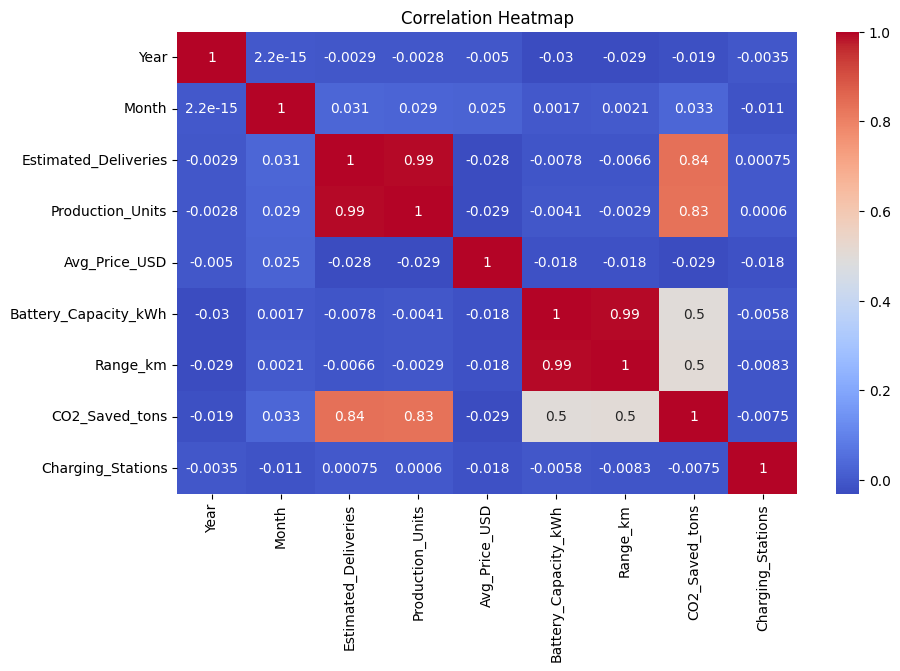

In [7]:
plt.figure(figsize = (10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

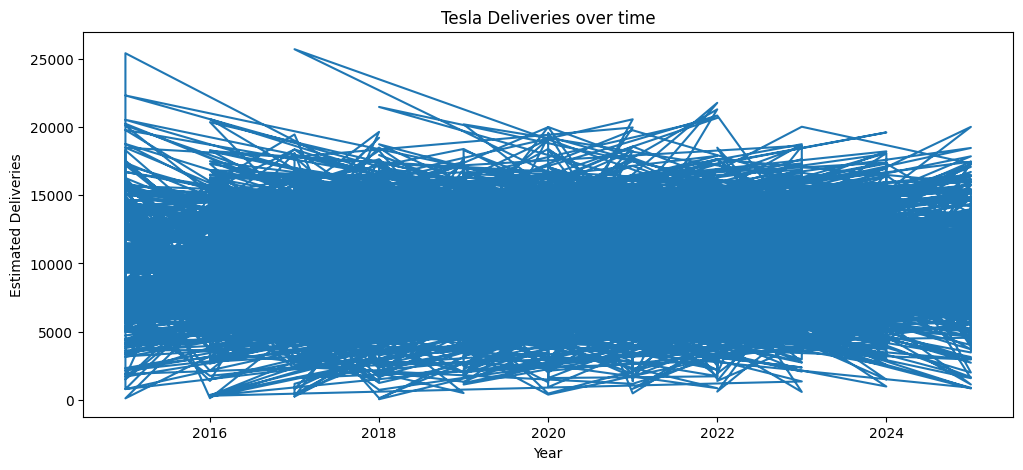

In [11]:
plt.figure(figsize=(12,5))
plt.plot(df['Year'],df['Estimated_Deliveries'])
plt.title("Tesla Deliveries over time")
plt.xlabel("Year")
plt.ylabel("Estimated Deliveries")
plt.show()

In [12]:
#Feature Engineering

df['Growth_Rate'] = df['Estimated_Deliveries'].pct_change()

df.dropna(inplace=True)

In [14]:
#Preparing data
X=df[['Year']]
y=df['Estimated_Deliveries']

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X,y,
    test_size = 0.2,
    random_state=42
)

In [17]:
#Linear Regression
lr = LinearRegression()
lr.fit(X_train,y_train)
y_pred = lr.predict(X_test)


In [18]:
#Evaluation
mae = mean_absolute_error(y_test,y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE: 3203.0053820794637
RMSE: 4025.936947173745
R2 Score: -0.003996847660626468


In [19]:
#Random Forest Model
rf = RandomForestRegressor(random_state=42)
rf.fit(X_train, y_train)
rf_pred=rf.predict(X_test)

In [21]:
#Hyperparameter Tuning
params = {
    'n_estimators':[50, 100],
    'max_depth':[3,5,10]
}

grid = GridSearchCV(
    RandomForestRegressor(random_state=42),
    params,
    cv=3
)
grid.fit(X_train, y_train)
print(grid.best_params_)

{'max_depth': 3, 'n_estimators': 50}


In [24]:
#Time Series Forecasting
model = ARIMA(df['Estimated_Deliveries'], order=(1,1,1))

model_fit = model.fit()
forecast = model_fit.forecast(steps=5)
print(forecast)


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)


2639    10237.531472
2640     9901.810031
2641     9916.643014
2642     9915.987657
2643     9916.016612
Name: predicted_mean, dtype: float64


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


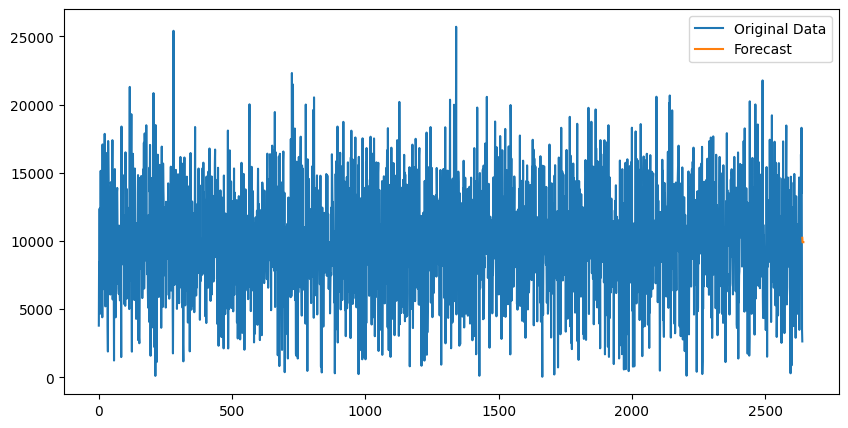

In [25]:
#Forecast Visualization
plt.figure(figsize=(10,5))
plt.plot(df['Estimated_Deliveries'], label='Original Data')
plt.plot(
    range(len(df), len(df)+5),
    forecast,
    label='Forecast'
)

plt.legend()
plt.show()